# Track A Baseline: Pretrained ResNet-18 Fine Tuning

이 노트북의 목표는 `RS18A` 데이터로 ImageNet pretrained ResNet-18 baseline을 학습하고, Track A 제출 형식의 CSV를 생성하는 것이다.

- 데이터: `data/RS18A`
- 모델: `torchvision.models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)`
- 출력: `id,dusty_prob`
- 최종 저장: `submissionA_resnet18_finetune.csv`

ResNet-18은 ImageNet에서 학습한 일반 이미지 feature를 가져와 태양광 패널의 clean/dusty 이진 분류에 맞게 fine-tuning한다. 여기서는 제출 가능한 `dusty_prob`를 안정적으로 만드는 것을 우선한다.


In [1]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights
from torchinfo import summary

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))

device: cuda
gpu: NVIDIA GeForce RTX 4070 SUPER


In [2]:
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != 'Quest02':
    # VSCode/Jupyter에서 다른 cwd로 열었을 때도 노트북 위치 기준 경로를 맞춘다.
    PROJECT_DIR = Path('/home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02')

DATA_DIR = PROJECT_DIR / 'data' / 'RS18A'
TRAIN_DIR = DATA_DIR / 'train'
TEST_DIR = DATA_DIR / 'test'
TRAIN_LABELS_PATH = DATA_DIR / 'train_labels.csv'
SAMPLE_SUBMISSION_PATH = DATA_DIR / 'sample_submission.csv'

MODEL_DIR = PROJECT_DIR / 'model'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = MODEL_DIR / 'base0_resnet18_finetune_best.pt'
HISTORY_PATH = MODEL_DIR / 'base0_resnet18_finetune_history.csv'
CONFIG_PATH = MODEL_DIR / 'base0_resnet18_finetune_config.json'
CURVE_PATH = MODEL_DIR / 'base0_resnet18_finetune_learning_curves.png'
RESULT_PATH = PROJECT_DIR / 'submissionA_resnet18_finetune.csv'

for path in [DATA_DIR, TRAIN_DIR, TEST_DIR, TRAIN_LABELS_PATH, SAMPLE_SUBMISSION_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

print('PROJECT_DIR:', PROJECT_DIR)
print('DATA_DIR:', DATA_DIR)
print('MODEL_DIR:', MODEL_DIR)
print('RESULT_PATH:', RESULT_PATH)


PROJECT_DIR: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02
DATA_DIR: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/data/RS18A
MODEL_DIR: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/model
RESULT_PATH: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/submissionA_resnet18_finetune.csv


## 1. 데이터 확인

`test`에는 정답 라벨이 없기 때문에 여기서 AUC를 계산하면 안 된다. AUC는 `train_labels.csv`가 있는 train 데이터를 다시 train/validation으로 나눠 validation에서만 계산한다.

In [3]:
train_df = pd.read_csv(TRAIN_LABELS_PATH)
submission_template = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print('train_df shape:', train_df.shape)
print(train_df.head())
print('\nlabel counts:')
print(train_df['label'].value_counts().sort_index())
print('\nlabel ratio:')
print(train_df['label'].value_counts(normalize=True).sort_index())

print('\nsubmission_template shape:', submission_template.shape)
print(submission_template.head())

train_df shape: (1366, 2)
            id  label
0  train_00000      0
1  train_00001      1
2  train_00002      0
3  train_00003      1
4  train_00004      1

label counts:
0    813
1    553
Name: label, dtype: int64

label ratio:
0    0.595168
1    0.404832
Name: label, dtype: float64

submission_template shape: (468, 2)
           id  dusty_prob
0  test_00000         0.5
1  test_00001         0.5
2  test_00002         0.5
3  test_00003         0.5
4  test_00004         0.5


In [4]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def image_path_from_id(image_dir, image_id):
    for ext in IMAGE_EXTENSIONS:
        candidate = image_dir / f'{image_id}{ext}'
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'Image not found for id={image_id} in {image_dir}')

train_missing = []
for image_id in train_df['id']:
    try:
        image_path_from_id(TRAIN_DIR, image_id)
    except FileNotFoundError:
        train_missing.append(image_id)

test_missing = []
for image_id in submission_template['id']:
    try:
        image_path_from_id(TEST_DIR, image_id)
    except FileNotFoundError:
        test_missing.append(image_id)

print('train missing images:', len(train_missing))
print('test missing images:', len(test_missing))

if train_missing or test_missing:
    raise FileNotFoundError('Some image ids do not match image files.')

train missing images: 0
test missing images: 0


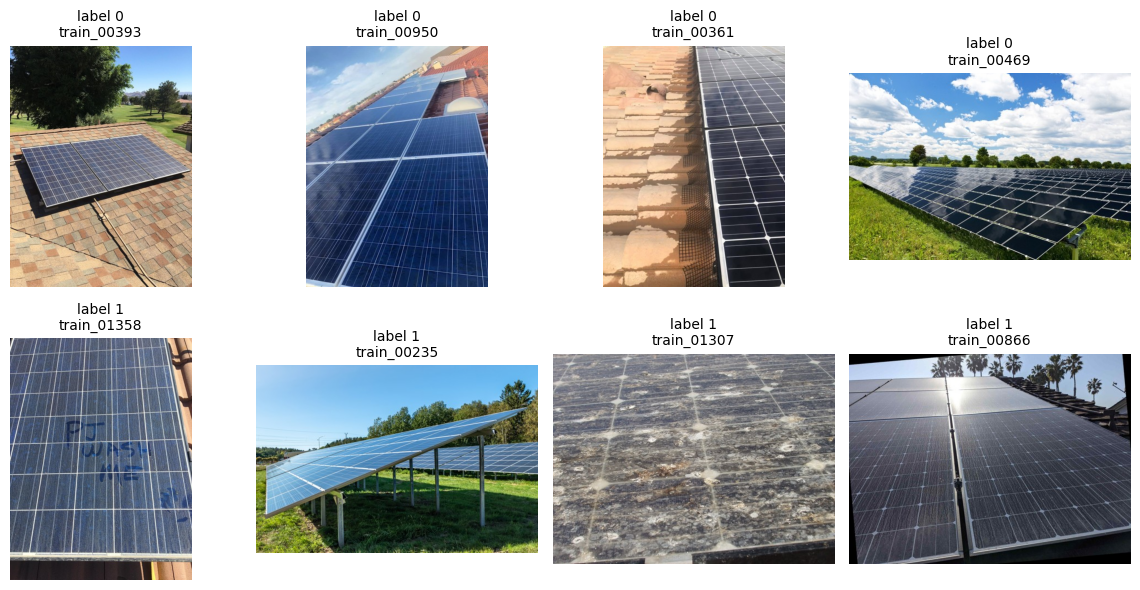

In [5]:
def show_label_samples(df, n_per_label=4):
    sample_parts = []
    for label in sorted(df['label'].unique()):
        part = df[df['label'] == label].sample(n=min(n_per_label, (df['label'] == label).sum()), random_state=SEED)
        sample_parts.append(part)
    sample_df = pd.concat(sample_parts).reset_index(drop=True)

    fig, axes = plt.subplots(2, n_per_label, figsize=(3 * n_per_label, 6))
    axes = np.array(axes).reshape(2, n_per_label)

    for row_idx, label in enumerate(sorted(df['label'].unique())):
        label_df = sample_df[sample_df['label'] == label].reset_index(drop=True)
        for col_idx in range(n_per_label):
            ax = axes[row_idx, col_idx]
            ax.axis('off')
            if col_idx >= len(label_df):
                continue
            image_id = label_df.loc[col_idx, 'id']
            image = Image.open(image_path_from_id(TRAIN_DIR, image_id)).convert('RGB')
            ax.imshow(image)
            ax.set_title(f'label {label}\n{image_id}', fontsize=10)

    plt.tight_layout()
    plt.show()

show_label_samples(train_df, n_per_label=4)

## 2. Dataset과 Transform

이번 baseline에서는 증강을 사용하지 않는다. train/validation/test 모두 같은 전처리를 적용한다.

`Resize(256) -> CenterCrop(224) -> ToTensor -> ImageNet Normalize`

pretrained ResNet-18은 ImageNet 이미지 분포로 학습되었기 때문에, 입력 크기와 정규화도 ImageNet 기준에 맞춘다.

In [6]:
weights = ResNet18_Weights.IMAGENET1K_V1
imagenet_mean = weights.transforms().mean
imagenet_std = weights.transforms().std

base_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

print('ImageNet mean:', imagenet_mean)
print('ImageNet std:', imagenet_std)


ImageNet mean: [0.485, 0.456, 0.406]
ImageNet std: [0.229, 0.224, 0.225]


In [7]:
class SolarPanelDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, has_label=True):
        self.df = dataframe.reset_index(drop=True).copy()
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.has_label = has_label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = row['id']
        image_path = image_path_from_id(self.image_dir, image_id)
        image = Image.open(image_path).convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        if self.has_label:
            label = torch.tensor(int(row['label']), dtype=torch.long)
            return image, label
        return image, image_id

In [8]:
VAL_RATIO = 0.2
BATCH_SIZE = 16
NUM_WORKERS = 0  # 안정성을 우선한 기본값입니다. 환경이 안정적이면 2로 올려도 됩니다.
PIN_MEMORY = torch.cuda.is_available()

train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=VAL_RATIO,
    random_state=SEED,
    stratify=train_df['label'],
)

train_split_df = train_split_df.reset_index(drop=True)
val_split_df = val_split_df.reset_index(drop=True)

print('train split:', train_split_df.shape)
print(train_split_df['label'].value_counts().sort_index())
print('\nvalidation split:', val_split_df.shape)
print(val_split_df['label'].value_counts().sort_index())

train_dataset = SolarPanelDataset(train_split_df, TRAIN_DIR, transform=base_transform, has_label=True)
val_dataset = SolarPanelDataset(val_split_df, TRAIN_DIR, transform=base_transform, has_label=True)
test_dataset = SolarPanelDataset(submission_template[['id']], TEST_DIR, transform=base_transform, has_label=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

train split: (1092, 2)
0    650
1    442
Name: label, dtype: int64

validation split: (274, 2)
0    163
1    111
Name: label, dtype: int64


In [9]:
# DataLoader smoke test
images, labels = next(iter(train_loader))
print('image batch shape:', images.shape)
print('label batch shape:', labels.shape)
print('labels:', labels[:10].tolist())

image batch shape: torch.Size([16, 3, 224, 224])
label batch shape: torch.Size([16])
labels: [0, 0, 0, 1, 1, 0, 0, 0, 0, 0]


## 3. 모델 구성

ResNet-18의 기본 출력은 ImageNet 1000개 class용이다. 이번 문제는 `Clean(0) / Dusty(1)` 이진 분류이므로 마지막 `fc`만 2개 class 출력으로 바꾼다.

- 입력 shape: `(batch, 3, 224, 224)`
- 출력 logits shape: `(batch, 2)`
- 전체 layer를 학습하는 full fine tuning으로 진행한다.


In [10]:
def build_resnet18(num_classes=2):
    model = models.resnet18(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    for param in model.parameters():
        param.requires_grad = True
    return model

model = build_resnet18(num_classes=2).to(device)
print('model parameters:', f'{sum(p.numel() for p in model.parameters()):,}')
print('trainable parameters:', f'{sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


model parameters: 11,177,538
trainable parameters: 11,177,538


In [11]:
try:
    summary(
        model,
        input_size=(BATCH_SIZE, 3, 224, 224),
        col_names=('input_size', 'output_size', 'num_params', 'trainable'),
        depth=2,
        device=device,
    )
except Exception as e:
    print('torchinfo.summary failed:', repr(e))

/home/thkim0/venv/v1/lib/python3.10/site-packages/torch/nn/modules/conv.py:459: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


In [12]:
# Model forward smoke test
model.eval()
with torch.no_grad():
    sample_images = images.to(device)
    sample_logits = model(sample_images)
    sample_probs = torch.softmax(sample_logits, dim=1)[:, 1]

print('logits shape:', sample_logits.shape)
print('dusty prob shape:', sample_probs.shape)
print('prob min/max:', float(sample_probs.min()), float(sample_probs.max()))

logits shape: torch.Size([16, 2])
dusty prob shape: torch.Size([16])
prob min/max: 0.3916378319263458 0.8915972709655762


## 4. 학습과 검증

test에는 정답이 없으므로 여기서 평가하지 않는다. `val_auc`는 train에서 떼어낸 validation split에서만 계산한다.

In [13]:
EPOCHS = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

config = {
    'seed': SEED,
    'data_dir': str(DATA_DIR),
    'model': 'torchvision.models.resnet18',
    'weights': 'ResNet18_Weights.IMAGENET1K_V1',
    'num_classes': 2,
    'fine_tuning': 'full',
    'val_ratio': VAL_RATIO,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'optimizer': 'AdamW',
    'loss': 'CrossEntropyLoss',
    'augmentation': 'none',
    'transform': 'Resize(256) -> CenterCrop(224) -> ToTensor -> ImageNet Normalize',
    'checkpoint_path': str(CHECKPOINT_PATH),
    'history_path': str(HISTORY_PATH),
    'submission_path': str(RESULT_PATH),
}

with CONFIG_PATH.open('w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print('saved config:', CONFIG_PATH)


saved config: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/model/base0_resnet18_finetune_config.json


In [14]:
def train_one_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        probs = torch.softmax(logits, dim=1)[:, 1]
        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy().tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    return avg_loss, acc, auc


def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = loss_fn(logits, labels)
            probs = torch.softmax(logits, dim=1)[:, 1]

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            all_labels.extend(labels.detach().cpu().numpy().tolist())
            all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy().tolist())
            all_probs.extend(probs.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    return avg_loss, acc, auc


In [15]:
history = []
best_val_auc = -1.0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_auc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    val_loss, val_acc, val_auc = evaluate(model, val_loader, loss_fn, device)

    row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'train_auc': train_auc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_auc': val_auc,
        'loss_gap_val_minus_train': val_loss - train_loss,
        'auc_gap_train_minus_val': train_auc - val_auc,
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_auc={train_auc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_auc={val_auc:.4f} | "
        f"auc_gap={train_auc - val_auc:.4f}"
    )

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(
            {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_auc': best_val_auc,
                'config': config,
            },
            CHECKPOINT_PATH,
        )
        print(f'  -> saved best checkpoint: {CHECKPOINT_PATH}')

history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_PATH, index=False)
print('best_val_auc:', best_val_auc)
print('saved history:', HISTORY_PATH)


Epoch 01/10 | train_loss=0.6257 train_acc=0.6703 train_auc=0.7186 | val_loss=0.6425 val_acc=0.6533 val_auc=0.7606 | auc_gap=-0.0420
  -> saved best checkpoint: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/model/base0_resnet18_finetune_best.pt
Epoch 02/10 | train_loss=0.2973 train_acc=0.8819 train_auc=0.9477 | val_loss=0.6996 val_acc=0.7190 val_auc=0.7753 | auc_gap=0.1724
  -> saved best checkpoint: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/model/base0_resnet18_finetune_best.pt
Epoch 03/10 | train_loss=0.1650 train_acc=0.9460 train_auc=0.9837 | val_loss=0.7538 val_acc=0.7080 val_auc=0.7573 | auc_gap=0.2265
Epoch 04/10 | train_loss=0.1136 train_acc=0.9625 train_auc=0.9922 | val_loss=0.7990 val_acc=0.7007 val_auc=0.7690 | auc_gap=0.2232
Epoch 05/10 | train_loss=0.0931 train_acc=0.9679 train_auc=0.9948 | val_loss=0.8511 val_acc=0.7409 val_auc=0.7937 | auc_gap=0.2011
  -> saved best checkpoint: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/model/base0_resnet18_f

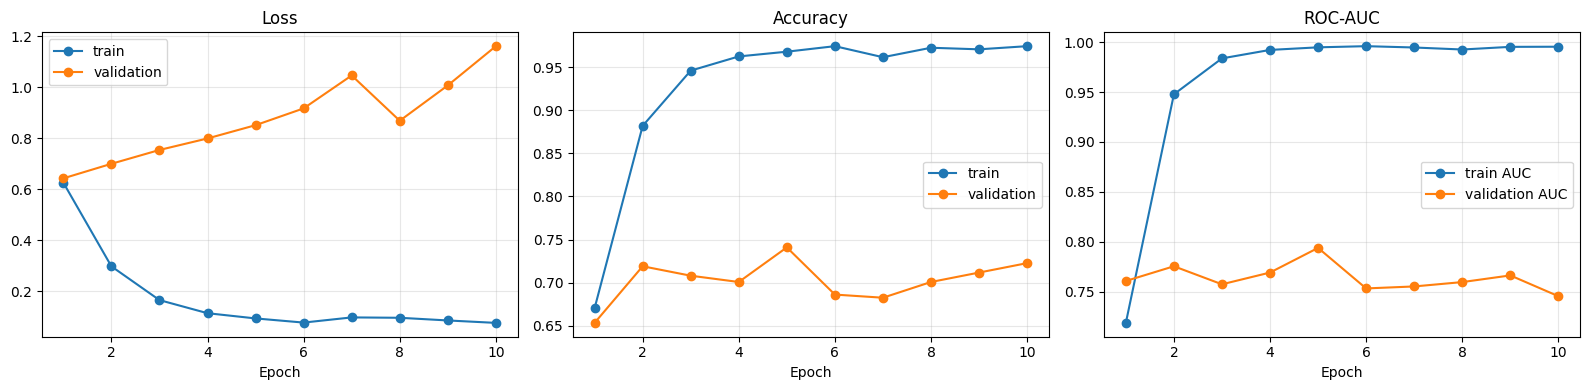

saved curve: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/model/base0_resnet18_finetune_learning_curves.png


,epoch,train_loss,val_loss,loss_gap_val_minus_train,train_auc,val_auc,auc_gap_train_minus_val
0,1,0.625701,0.642547,0.016845,0.718562,0.760570,-0.042008
1,2,0.297310,0.699622,0.402312,0.947738,0.775327,0.172410
2,3,0.165036,0.753834,0.588798,0.983738,0.757254,0.226484
3,4,0.113630,0.798976,0.685346,0.992221,0.769027,0.223194
4,5,0.093143,0.851076,0.757933,0.994817,0.793732,0.201085
5,6,0.076870,0.916887,0.840016,0.995983,0.753109,0.242874
6,7,0.097133,1.046076,0.948943,0.994654,0.755099,0.239555
7,8,0.095688,0.868454,0.772766,0.992635,0.759465,0.233170
8,9,0.085185,1.007071,0.921887,0.995298,0.766153,0.229145
9,10,0.075661,1.160900,1.085239,0.995430,0.745316,0.250114


In [16]:
history_df = pd.read_csv(HISTORY_PATH)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train')
axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_acc'], marker='o', label='train')
axes[1].plot(history_df['epoch'], history_df['val_acc'], marker='o', label='validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(history_df['epoch'], history_df['train_auc'], marker='o', label='train AUC')
axes[2].plot(history_df['epoch'], history_df['val_auc'], marker='o', label='validation AUC')
axes[2].set_title('ROC-AUC')
axes[2].set_xlabel('Epoch')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig(CURVE_PATH, dpi=150, bbox_inches='tight')
plt.show()
print('saved curve:', CURVE_PATH)

display(history_df[[
    'epoch',
    'train_loss', 'val_loss', 'loss_gap_val_minus_train',
    'train_auc', 'val_auc', 'auc_gap_train_minus_val',
]])


## 5. Track A 제출 CSV 생성

test에는 정답 라벨이 없으므로 `evaluate()`를 사용하지 않는다. best checkpoint를 불러와 `dusty_prob`만 예측하고, `data/RS18A/sample_submission.csv`의 `id` 순서와 같은 `id,dusty_prob` 형식으로 `submissionA_resnet18_finetune.csv`를 저장한다.


In [17]:
def predict_test(model, dataloader, device):
    model.eval()
    image_ids = []
    dusty_probs = []

    with torch.no_grad():
        for images, batch_ids in dataloader:
            images = images.to(device, non_blocking=PIN_MEMORY)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)[:, 1]

            image_ids.extend(list(batch_ids))
            dusty_probs.extend(probs.detach().cpu().numpy().tolist())

    return pd.DataFrame({"id": image_ids, "dusty_prob": dusty_probs})


checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
print("loaded checkpoint epoch:", checkpoint["epoch"])
print("loaded best_val_auc:", checkpoint["best_val_auc"])

pred_df = predict_test(model, test_loader, device)

# sample_submission의 id 순서를 기준으로 정렬한다.
result_df = submission_template[["id"]].merge(pred_df, on="id", how="left")

expected_columns = ["id", "dusty_prob"]
if result_df.columns.tolist() != expected_columns:
    raise ValueError(f"submission columns mismatch: {result_df.columns.tolist()}")

if len(result_df) != len(submission_template):
    raise ValueError(
        f"submission row count mismatch: {len(result_df)} != {len(submission_template)}"
    )

if result_df["id"].tolist() != submission_template["id"].tolist():
    raise ValueError("submission id order does not match sample_submission.csv")

if result_df["dusty_prob"].isna().any():
    raise ValueError("Some test ids were not predicted.")

if not result_df["dusty_prob"].between(0.0, 1.0).all():
    raise ValueError("dusty_prob must be in [0, 1].")

result_df.to_csv(RESULT_PATH, index=False)

print("saved submission:", RESULT_PATH)
print("submission shape:", result_df.shape)
print("submission columns:", result_df.columns.tolist())
display(result_df.head())
display(result_df["dusty_prob"].describe())


loaded checkpoint epoch: 5
loaded best_val_auc: 0.7937323826894379
saved submission: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/submissionA_resnet18_finetune.csv
submission shape: (468, 2)
submission columns: ['id', 'dusty_prob']


,id,dusty_prob
0,test_00000,0.975670
1,test_00001,0.053246
2,test_00002,0.015040
3,test_00003,0.031874
4,test_00004,0.252531


count    4.680000e+02
mean     3.413103e-01
std      3.844580e-01
min      2.560436e-08
25%      9.604319e-03
50%      1.284836e-01
75%      7.346280e-01
max      9.999746e-01
Name: dusty_prob, dtype: float64

## 정리

이 노트북은 Track A용 ResNet-18 fine-tuning baseline이다.

- validation AUC는 train split에서 떼어낸 validation 데이터로만 계산한다.
- test에는 정답 라벨이 없으므로 `dusty_prob` 예측만 생성한다.
- 최종 파일 `submissionA_resnet18_finetune.csv`는 `data/RS18A/sample_submission.csv`와 같은 `id,dusty_prob` 형식을 따른다.
- `dusty_prob`는 모델이 해당 이미지를 dusty class로 판단한 softmax 확률이다.
